# Decision Tree Classifier

---

## Intuition

A decision tree sorts data into branches based on feature values, arriving at a prediction at each leaf.
At each internal node the model asks a yes/no question (e.g. *Is BMI > 30?*) and routes samples left or right.
The goal is to produce **pure** subsets where one class dominates.

## Splitting Criterion: Gini Impurity

At each node we choose the feature $j$ and threshold $t$ that maximizes the **Gini gain**:

$$\text{Gain}(j, t) = \text{Gini}(\text{parent}) - \frac{N_L}{N}\,\text{Gini}(\text{left}) - \frac{N_R}{N}\,\text{Gini}(\text{right})$$

The **Gini impurity** of a node with class distribution $\{p_k\}$ is:

$$\text{Gini} = 1 - \sum_{k} p_k^2$$

- $\text{Gini} = 0$ when the node is perfectly pure (one class only).
- $\text{Gini}$ is maximized when all classes are equally represented.

A **leaf node** returns the majority class of its training samples.

## How a Decision Tree is Built

1. Start at the root with all training samples.
2. For each feature, compute the Gini gain for every possible threshold.
3. Choose the split with the highest gain.
4. Recursively repeat for each child node until:
   - Maximum depth is reached, or
   - A node has fewer than `min_samples_split` samples.
5. Label each leaf with the majority class in that subset.

## Advantages and Disadvantages

**Advantages**
- Easy to interpret and visualize.
- Handles both numerical and categorical features.
- No feature scaling required.
- Non-parametric: makes no assumptions about data distribution.

**Disadvantages**
- Prone to overfitting when depth is unconstrained.
- Unstable: small changes in data can produce very different trees.
- Axis-aligned splits miss diagonal boundaries.

**Solutions**
- Limit `max_depth` or `min_samples_split` (pruning).
- Use ensemble methods: Random Forest or Gradient Boosting.

## Summary

- Gini impurity quantifies node impurity.
- Gini gain measures how much a split reduces impurity.
- Trees are built greedily by picking the best split at each level.
- Depth controls the bias-variance tradeoff.

---

**Dataset:** Obesity Levels (`Obesity_levels.csv`). Falls back to sklearn iris if `FileNotFoundError`.
**Task:** Classify obesity category from health and lifestyle features.


In [28]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

sns.set_theme()

from rice_ml.supervised_learning import DecisionTreeClassifier
from rice_ml.preprocess import train_test_split
from rice_ml.metrics import accuracy_score, confusion_matrix


In [29]:
try:
    import pandas as pd
    df = pd.read_csv('../../../data/Obesity_levels.csv')
    from rice_ml.preprocess import OrdinalEncoder
    cat_cols = df.select_dtypes(include='object').columns.tolist()
    for col in cat_cols:
        enc = OrdinalEncoder()
        df[col] = enc.fit_transform(df[[col]]).ravel()
    target_col = 'NObeyesdad' if 'NObeyesdad' in df.columns else df.columns[-1]
    X = df.drop(columns=[target_col]).values.astype(float)
    y = df[target_col].values.astype(int)
    class_names = [str(c) for c in np.unique(y)]
    print(f'Loaded obesity dataset: {X.shape}')
except FileNotFoundError:
    from sklearn.datasets import load_iris
    iris = load_iris()
    X, y = iris.data, iris.target
    class_names = list(iris.target_names)
    print('CSV not found. using iris dataset (3 classes)')


Loaded obesity dataset: (2111, 16)


## Dataset Description

The **Obesity Levels** dataset contains 2111 samples with 16 features related to eating habits,
physical activity, and demographics. The target column `NObeyesdad` has 7 obesity categories.

| Feature | Description |
|---|---|
| Gender | Male / Female |
| Age | Age in years |
| Height / Weight | Body measurements |
| FAVC | Frequent consumption of high-calorie food |
| FCVC | Frequency of vegetable consumption |
| NCP | Number of main meals per day |
| CAEC | Snacking between meals |
| CH2O | Daily water intake |
| FAF | Physical activity frequency |
| TUE | Time on technology devices |
| CALC | Alcohol consumption |
| MTRANS | Mode of transportation |
| NObeyesdad | **Target**: obesity level (7 classes) |


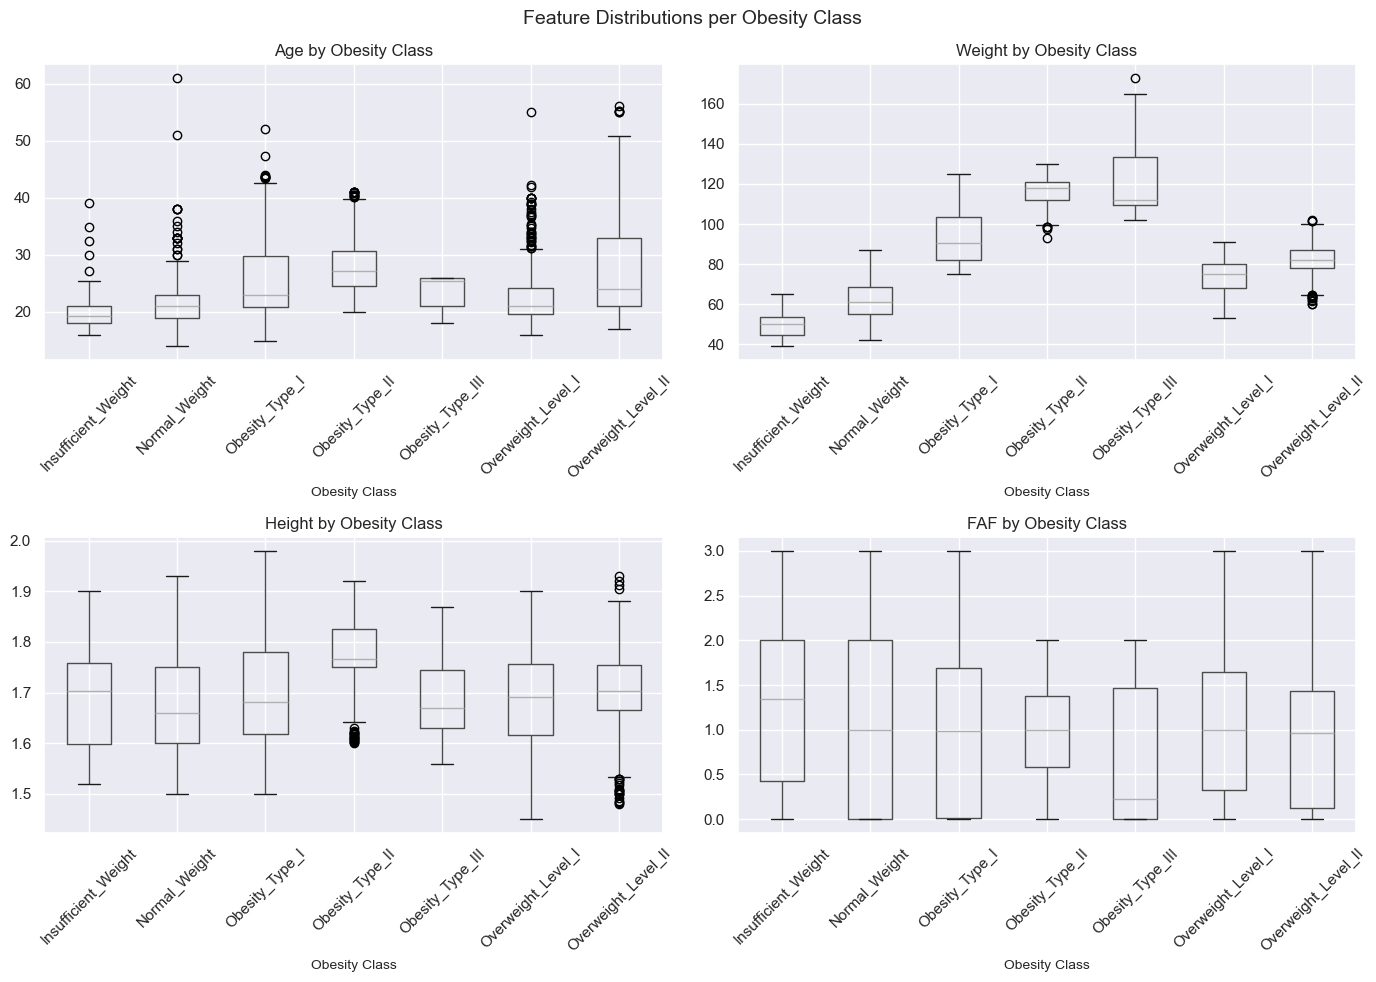

In [30]:
# Boxplots: distribution of key features per obesity class
try:
    import pandas as pd
    df_plot = pd.read_csv('../../../data/Obesity_levels.csv')
    plot_features = ['Age', 'Weight', 'Height', 'FAF']
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    for ax, feat in zip(axes.ravel(), plot_features):
        df_plot.boxplot(column=feat, by='NObeyesdad', ax=ax)
        ax.set_title(f'{feat} by Obesity Class', fontsize=12)
        ax.set_xlabel('Obesity Class', fontsize=10)
        ax.tick_params(axis='x', rotation=45)
    plt.suptitle('Feature Distributions per Obesity Class', fontsize=14)
    plt.tight_layout()
    plt.show()
except FileNotFoundError:
    print('CSV not found. Skipping boxplots.')


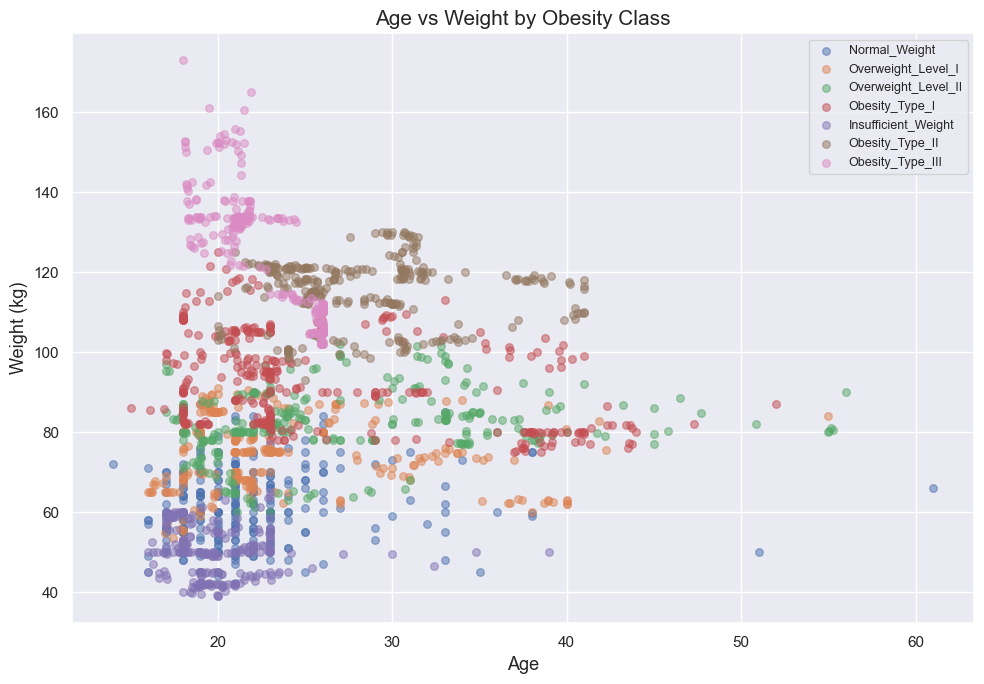

In [31]:
# Scatter: Age vs Weight colored by obesity class
try:
    import pandas as pd
    df_plot = pd.read_csv('../../../data/Obesity_levels.csv')
    plt.figure(figsize=(10, 7))
    for cls in df_plot['NObeyesdad'].unique():
        sub = df_plot[df_plot['NObeyesdad'] == cls]
        plt.scatter(sub['Age'], sub['Weight'], label=cls, alpha=0.5, s=30)
    plt.xlabel('Age', fontsize=13)
    plt.ylabel('Weight (kg)', fontsize=13)
    plt.title('Age vs Weight by Obesity Class', fontsize=15)
    plt.legend(fontsize=9, bbox_to_anchor=(1, 1))
    plt.tight_layout()
    plt.show()
except FileNotFoundError:
    print('CSV not found. Skipping scatter plot.')


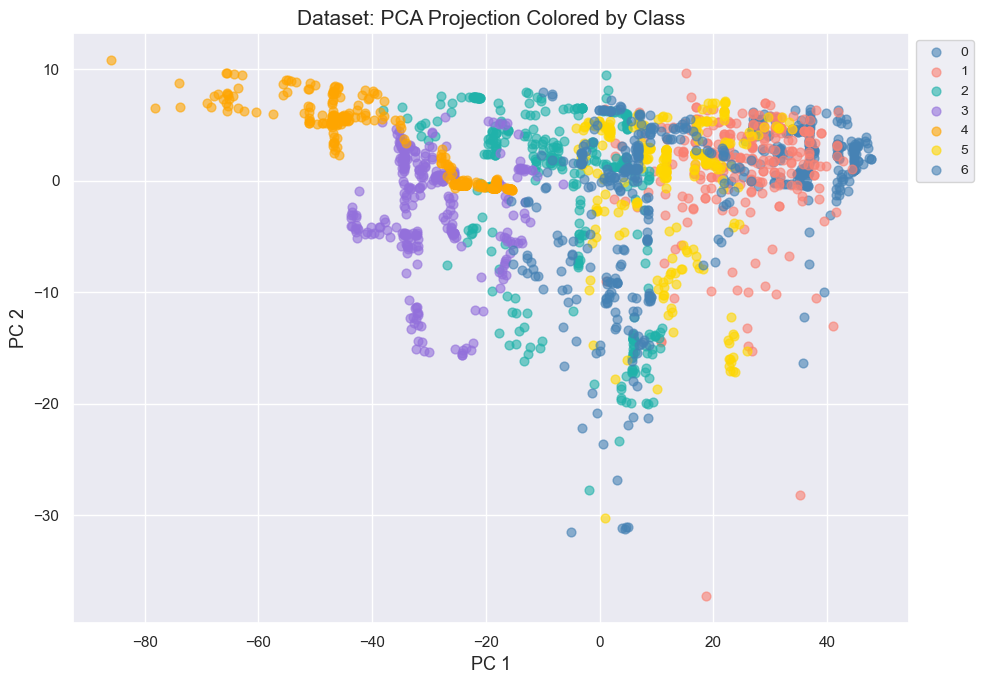

In [32]:
# EDA: visualize data in 2D using the first two features
from rice_ml.unsupervised_learning import PCA

pca_vis = PCA(n_components=2).fit(X)
X_2d = pca_vis.transform(X)

plt.figure(figsize=(10, 7))
colors = ['steelblue', 'salmon', 'lightseagreen', 'mediumpurple', 'orange', 'gold']
for i, cls in enumerate(class_names):
    mask = y == i
    plt.scatter(X_2d[mask, 0], X_2d[mask, 1],
                color=colors[i % len(colors)], label=cls, alpha=0.6, s=40)
plt.xlabel('PC 1', fontsize=13)
plt.ylabel('PC 2', fontsize=13)
plt.title('Dataset: PCA Projection Colored by Class', fontsize=15)
plt.legend(fontsize=10, bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()


In [33]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Effect of `max_depth` on Accuracy

Deeper trees fit training data better but may overfit. We compare train vs test accuracy across depths.

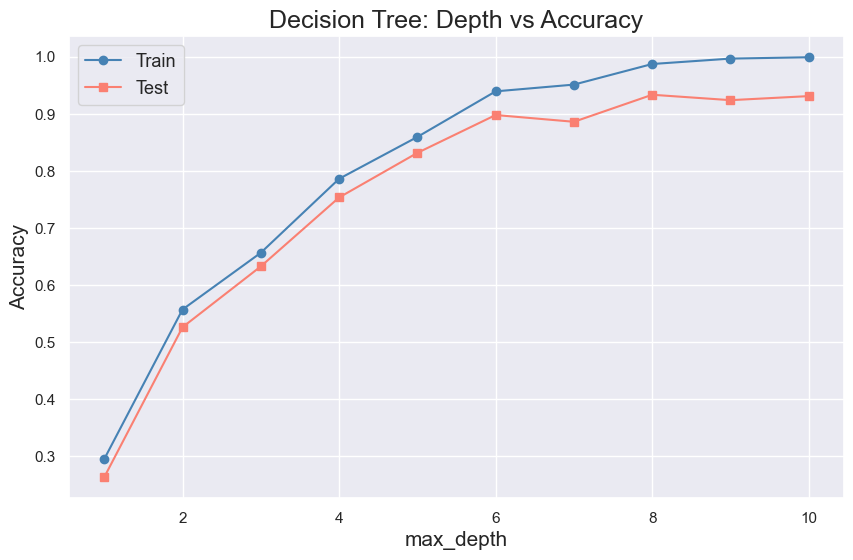

In [25]:
depths = range(1, 11)
train_accs, test_accs = [], []

for d in depths:
    clf = DecisionTreeClassifier(max_depth=d)
    clf.fit(X_train, y_train)
    train_accs.append(accuracy_score(y_train, clf.predict(X_train)))
    test_accs.append(accuracy_score(y_test, clf.predict(X_test)))

plt.figure(figsize=(10, 6))
plt.plot(depths, train_accs, marker='o', label='Train', color='steelblue')
plt.plot(depths, test_accs, marker='s', label='Test', color='salmon')
plt.xlabel('max_depth', fontsize=15)
plt.ylabel('Accuracy', fontsize=15)
plt.title('Decision Tree: Depth vs Accuracy', fontsize=18)
plt.legend(fontsize=13)
plt.show()

Best depth: 8
Test Accuracy: 0.9313


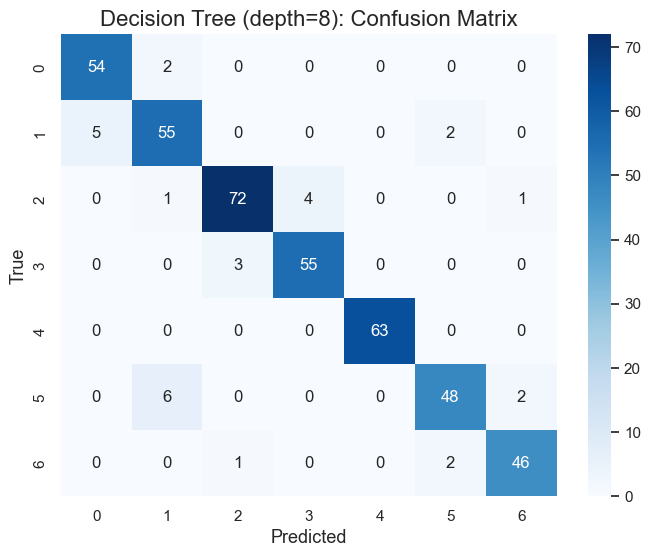

In [26]:
best_depth = depths[np.argmax(test_accs)]
clf = DecisionTreeClassifier(max_depth=best_depth)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print(f'Best depth: {best_depth}')
print(f'Test Accuracy: {accuracy_score(y_test, y_pred):.4f}')

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted', fontsize=13)
plt.ylabel('True', fontsize=13)
plt.title(f'Decision Tree (depth={best_depth}): Confusion Matrix', fontsize=16)
plt.show()

## Interpretation

- A **depth-1 tree** (decision stump) makes a single split. low complexity, often low accuracy.
- As depth increases, training accuracy rises toward 1.0 but test accuracy may plateau or decrease (overfitting).
- The optimal depth balances bias and variance. use cross-validation in practice to find it.

## Decision Boundary (2D PCA View)

Project data to 2 PCA components and fit a tree on the reduced space.
The colored regions show which class the tree predicts at each point in the 2D space.


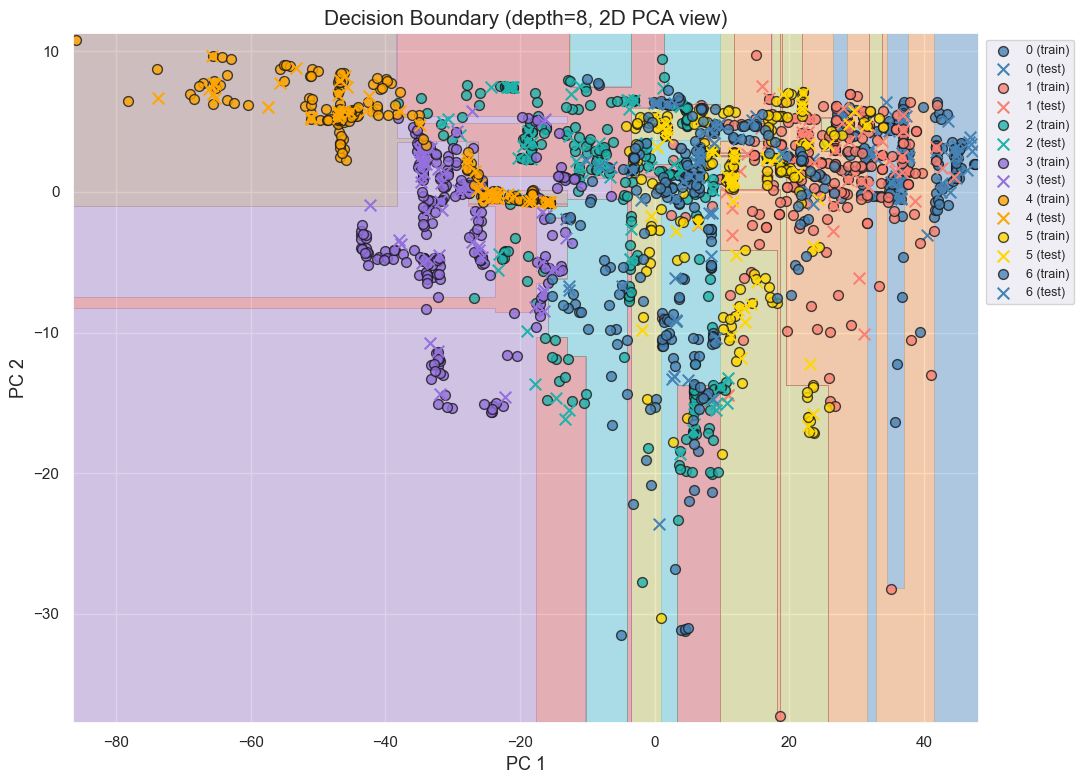

In [27]:
from rice_ml.unsupervised_learning import PCA

# Reduce to 2D for visualization
pca2 = PCA(n_components=2).fit(X)
X_2d_train = pca2.transform(X_train)
X_2d_test  = pca2.transform(X_test)

# Train a tree on the 2D projection
clf_2d = DecisionTreeClassifier(max_depth=best_depth)
clf_2d.fit(X_2d_train, y_train)

# Build mesh grid over the 2D space
h = 0.05
x_min, x_max = X_2d_train[:, 0].min() - 0.5, X_2d_train[:, 0].max() + 0.5
y_min, y_max = X_2d_train[:, 1].min() - 0.5, X_2d_train[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
Z = clf_2d.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(11, 8))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='tab10')
scatter_colors = ['steelblue', 'salmon', 'lightseagreen', 'mediumpurple', 'orange', 'gold']
for i, cls in enumerate(class_names):
    mask_tr = y_train == i
    mask_te = y_test  == i
    plt.scatter(X_2d_train[mask_tr, 0], X_2d_train[mask_tr, 1],
                color=scatter_colors[i % len(scatter_colors)],
                edgecolors='k', marker='o', s=50, alpha=0.8, label=f'{cls} (train)')
    plt.scatter(X_2d_test[mask_te, 0], X_2d_test[mask_te, 1],
                color=scatter_colors[i % len(scatter_colors)],
                marker='x', s=70, label=f'{cls} (test)')
plt.xlabel('PC 1', fontsize=13)
plt.ylabel('PC 2', fontsize=13)
plt.title(f'Decision Boundary (depth={best_depth}, 2D PCA view)', fontsize=15)
plt.legend(fontsize=9, bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()
